In [2]:
import rasterio
print("rasterio hazır!")

rasterio hazır!


In [3]:
veri = rasterio.open("n38_e032_1arc_v3.tif")
print(veri.crs)
print(veri.bounds)

EPSG:4326
BoundingBox(left=31.999861111111112, bottom=37.99986111111111, right=33.00013888888889, top=39.000138888888884)


In [4]:
print("Genişlik:", veri.width, "piksel")
print("Yükseklik:", veri.height, "piksel")
print("Toplam piksel:", veri.width * veri.height)

Genişlik: 3601 piksel
Yükseklik: 3601 piksel
Toplam piksel: 12967201


In [5]:
import numpy as np

yukseklik = veri.read(1)
print("Min yükseklik:", yukseklik.min(), "metre")
print("Max yükseklik:", yukseklik.max(), "metre")
print("Ortalama yükseklik:", yukseklik.mean().round(1), "metre")

Min yükseklik: 882 metre
Max yükseklik: 2155 metre
Ortalama yükseklik: 1094.4 metre


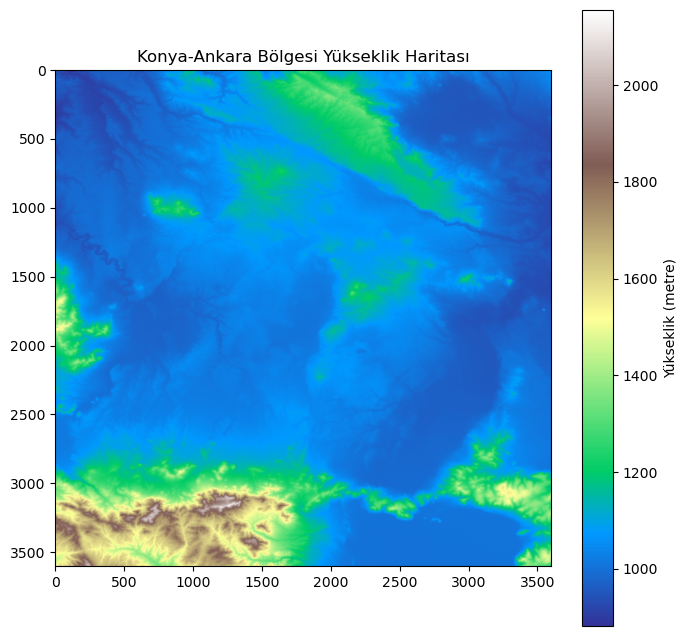

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(yukseklik, cmap="terrain")
plt.colorbar(label="Yükseklik (metre)")
plt.title("Konya-Ankara Bölgesi Yükseklik Haritası")
plt.show()

In [7]:
from rasterio.transform import rowcol
import numpy as np

# Piksel boyutu (derece cinsinden 1 arc-second = yaklaşık 30 metre)
piksel_metre = 30

# Yükseklik verisinden eğim hesapla
x_egim = np.gradient(yukseklik, piksel_metre, axis=1)
y_egim = np.gradient(yukseklik, piksel_metre, axis=0)
egim = np.sqrt(x_egim**2 + y_egim**2)
egim_derece = np.degrees(np.arctan(egim))

print("Min eğim:", egim_derece.min().round(2), "derece")
print("Max eğim:", egim_derece.max().round(2), "derece")
print("Ortalama eğim:", egim_derece.mean().round(2), "derece")

Min eğim: 0.0 derece
Max eğim: 60.25 derece
Ortalama eğim: 3.49 derece


In [8]:
# GES için kriter: eğim 5 dereceden az
uygun = egim_derece < 5

print("Toplam piksel:", egim_derece.size)
print("Uygun piksel:", uygun.sum())
print("Uygun oran:", (uygun.sum() / egim_derece.size * 100).round(1), "%")

Toplam piksel: 12967201
Uygun piksel: 10680545
Uygun oran: 82.4 %


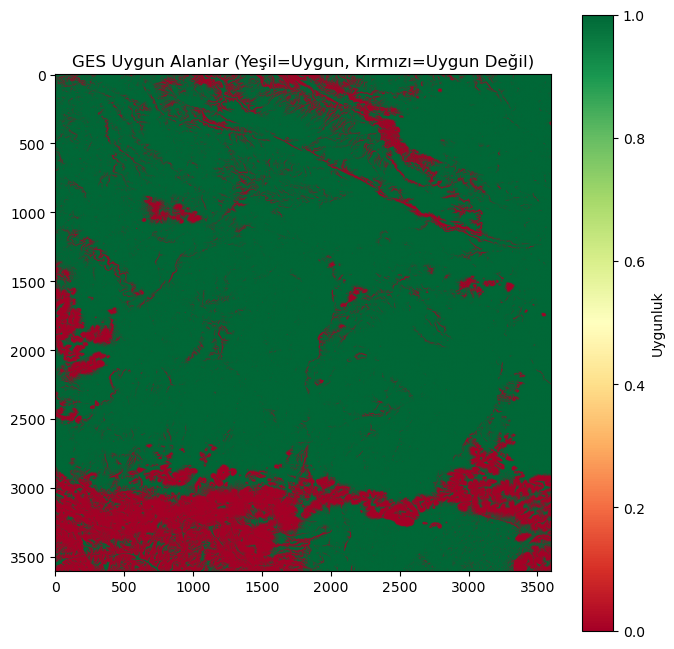

In [9]:
plt.figure(figsize=(8,8))
plt.imshow(uygun, cmap="RdYlGn")
plt.title("GES Uygun Alanlar (Yeşil=Uygun, Kırmızı=Uygun Değil)")
plt.colorbar(label="Uygunluk")
plt.savefig("ges_egim_uygunluk.png", dpi=150)
plt.show()

In [10]:
piksel_alan_m2 = 30 * 30  # her piksel 30x30 metre
uygun_m2 = uygun.sum() * piksel_alan_m2
uygun_hektar = uygun_m2 / 10000

print(f"Uygun alan: {uygun_hektar:,.0f} hektar")
print(f"Uygun alan: {uygun_hektar/100:,.0f} km²")

Uygun alan: 961,249 hektar
Uygun alan: 9,612 km²
